# 01 - 数据浏览与检查

加载采集的 `.npz` 数据，逐帧查看图像和动作曲线。

In [8]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

%matplotlib inline

# 项目根目录
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

## 1. 选择并加载数据文件

In [9]:
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'seq_rz_3d')

files = sorted(glob.glob(os.path.join(DATA_DIR, '*.npz')))
if not files:
    raise FileNotFoundError(f'未找到数据文件，请先运行采集脚本: {DATA_DIR}')

print(f'找到 {len(files)} 个数据文件:')
for i, f in enumerate(files):
    size_mb = os.path.getsize(f) / 1e3
    print(f'  [{i}] {os.path.basename(f)}  ({size_mb:.1f} KB)')

找到 10 个数据文件:
  [0] seq_000_rz_3d_1777292851.npz  (341.7 KB)
  [1] seq_001_rz_3d_1777292876.npz  (337.1 KB)
  [2] seq_002_rz_3d_1777292896.npz  (337.6 KB)
  [3] seq_003_rz_3d_1777292913.npz  (334.3 KB)
  [4] seq_004_rz_3d_1777292933.npz  (335.8 KB)
  [5] seq_005_rz_3d_1777292959.npz  (342.7 KB)
  [6] seq_006_rz_3d_1777292984.npz  (341.2 KB)
  [7] seq_007_rz_3d_1777293009.npz  (343.3 KB)
  [8] seq_008_rz_3d_1777293027.npz  (344.4 KB)
  [9] seq_009_rz_3d_1777293046.npz  (339.6 KB)


In [10]:
# 修改索引选择文件
FILE_INDEX = -1  # -1 表示最新的文件

data_path = files[FILE_INDEX]
data = np.load(data_path)

print(f'加载: {os.path.basename(data_path)}')
print(f'键: {list(data.keys())}')

images = data['images']
actions = data['actions']

print(f'\n数据统计:')
print(f'  总帧数:   {images.shape[0]}')
print(f'  图像尺寸: {images.shape[1:]}')
print(f'  动作维度: {actions.shape[1]}')
print(f'  动作范围: [{actions.min():.6f}, {actions.max():.6f}]')
if 'dt' in data:
    print(f'  采样间隔: {float(data["dt"]):.4f} s')

加载: seq_009_rz_3d_1777293046.npz
键: ['images', 'actions', 'dt', 'focal', 'H', 'W', 'camera_eye', 'camera_center', 'camera_up', 'positions', 'radii']

数据统计:
  总帧数:   500
  图像尺寸: (100, 100)
  动作维度: 2
  动作范围: [-0.003794, 0.000000]
  采样间隔: 0.0050 s


## 2. 全局动作曲线

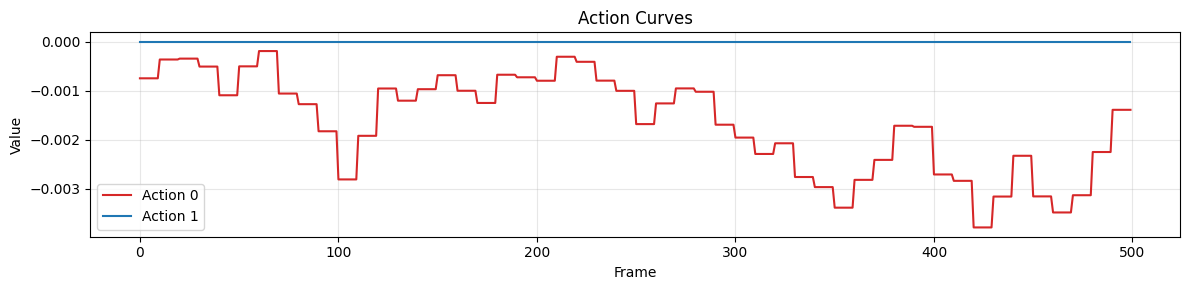

In [11]:
fig, ax = plt.subplots(figsize=(12, 3))
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']
for d in range(actions.shape[1]):
    ax.plot(actions[:, d], color=colors[d % len(colors)], label=f'Action {d}')
ax.set_xlabel('Frame')
ax.set_ylabel('Value')
ax.set_title('Action Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 逐帧浏览（交互式滑块）

In [ ]:
from IPython.display import display, clear_output
import ipywidgets as widgets

slider = widgets.IntSlider(min=0, max=len(images)-1, step=1, value=0, description='Frame')
out = widgets.Output()

def on_slider_change(change):
    with out:
        clear_output(wait=True)
        frame_idx = slider.value
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        ax1.imshow(images[frame_idx], cmap='gray', vmin=0, vmax=1)
        ax1.set_title(f'Frame {frame_idx}/{len(images)-1}')
        ax1.axis('off')
        for d in range(actions.shape[1]):
            ax2.plot(actions[:, d], color=colors[d % len(colors)], alpha=0.4, label=f'Action {d}')
        ax2.axvline(x=frame_idx, color='k', linestyle='--', linewidth=2)
        act_str = ', '.join([f'{v:.4f}' for v in actions[frame_idx]])
        ax2.set_title(f'Actions: [{act_str}]')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

slider.observe(on_slider_change, names='value')
display(slider, out)
on_slider_change(None)

IntSlider(value=0, description='Frame', max=499)

Output()

## 4. 网格预览（多帧一览）

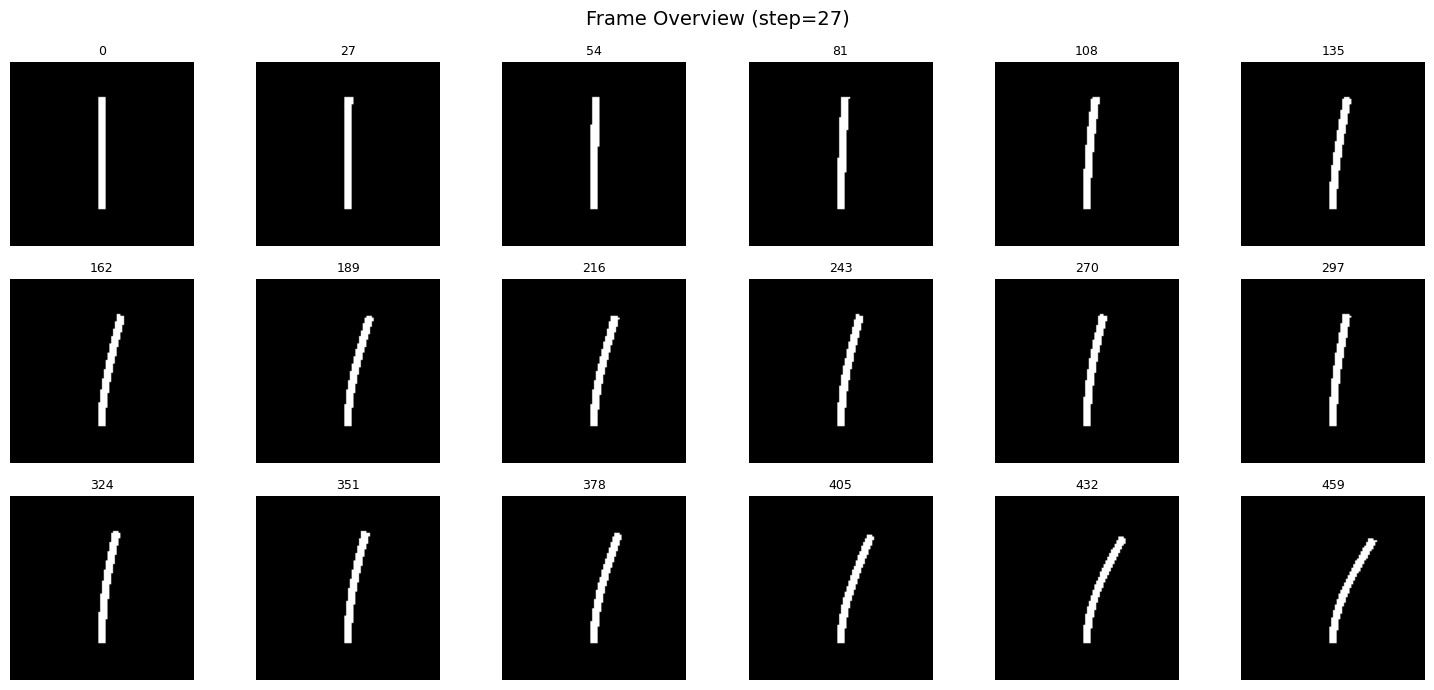

In [13]:
N_COLS = 6
N_ROWS = 3
N_SHOW = N_COLS * N_ROWS
step = max(1, len(images) // N_SHOW)
indices = list(range(0, len(images), step))[:N_SHOW]

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 7))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(images[idx], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{idx}', fontsize=9)
    ax.axis('off')
# 隐藏多余子图
for ax in axes.flat[len(indices):]:
    ax.axis('off')
plt.suptitle(f'Frame Overview (step={step})', fontsize=14)
plt.tight_layout()
plt.show()

## 5. 图像值分布检查

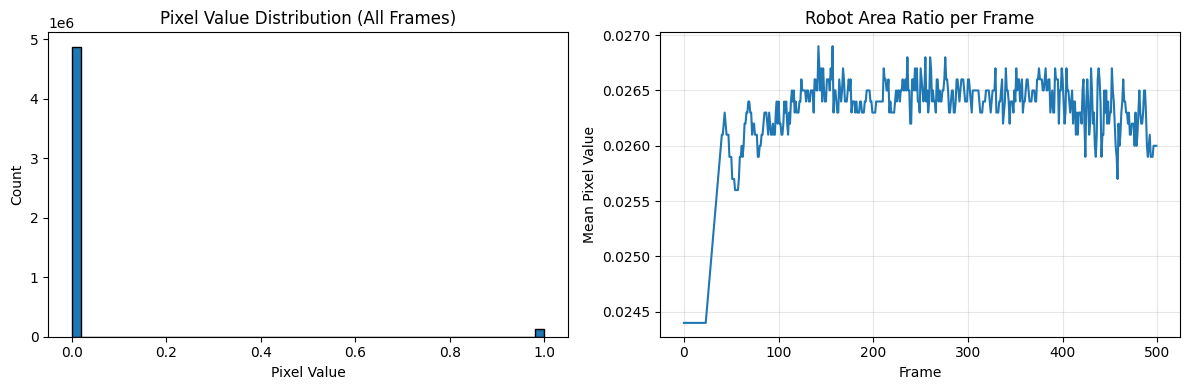

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 像素值直方图
ax1.hist(images.flatten(), bins=50, edgecolor='black')
ax1.set_title('Pixel Value Distribution (All Frames)')
ax1.set_xlabel('Pixel Value')
ax1.set_ylabel('Count')

# 每帧白色像素占比（= 机器人占比）
white_ratio = images.mean(axis=(1, 2))
ax2.plot(white_ratio)
ax2.set_title('Robot Area Ratio per Frame')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Mean Pixel Value')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()